# Recursive Chunking — Multi-PDF Experiment

This notebook evaluates **Recursive Character Text Splitting** across a whole folder of PDFs.

To add a new document: drop the PDF into `data/recursive_friendly/`, add its questions to
`data/ground_truth.json`, and re-run. Nothing in the code is tied to a specific file.
(The Markdown pipeline has been removed on purpose.)

Pipeline:

PDFs → Extract (per page) → Normalize → Chunk (per chunk size) → Embed →
Retrieve (one shared index over all PDFs) → Evaluate

**How retrieval is evaluated**

All PDFs are chunked and indexed *together*, so a question about asthma has to beat the
chunks of every other document. A retrieved chunk counts as **relevant** only if it comes
from the PDF the question belongs to *and* contains at least one of the question's
evidence phrases.

| Metric | Meaning |
|---|---|
| Precision@k | relevant chunks in the top k ÷ k |
| Recall@k | share of the question's evidence phrases found in the top k chunks |
| Hit rate@k | 1 if any top-k chunk is relevant, else 0 |
| MRR@k | 1 ÷ rank of the first relevant chunk (0 if none in the top k) |

Every metric is averaged over all questions.

In [39]:
from pathlib import Path
from collections import Counter
import json
import re
import unicodedata

import numpy as np
import pandas as pd
import pymupdf  # PyMuPDF
import matplotlib.pyplot as plt

from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer

## Configuration

Everything you are likely to tune lives in this one cell.

In [2]:
BASE_DIR = Path.cwd()
PDF_DIR = BASE_DIR / "data" / "recursive_friendly"
GROUND_TRUTH_PATH = BASE_DIR / "data" / "ground_truth.json"

# Chunking
CHUNK_SIZES = [200, 300, 400, 500, 700]
CHUNK_OVERLAP = 50
SEPARATORS = ["\n\n", "\n", ". ", " ", ""]

# Evaluation
K_VALUES = (1, 3, 5)
TOP_K = max(K_VALUES)

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

print("PDF folder:", PDF_DIR)
print("Ground truth:", GROUND_TRUTH_PATH)

PDF folder: /home/as/Downloads/Repos/DailyTask/Sessions/session-1-recursive-chunking/data/recursive_friendly
Ground truth: /home/as/Downloads/Repos/DailyTask/Sessions/session-1-recursive-chunking/data/ground_truth.json


## Document Ingestion

Document ingestion is the process of loading raw documents, extracting their
content, preserving useful metadata, and converting them into a standardized
representation that can be passed to the chunking stage.

In this experiment, two document types are used:

1. Recursive-friendly document
      - asthma_patient_information.pdf
      - who_cancer.pdf
      - who_cholera.pdf
      - who_covid19_clinical.pdf
      - who_diabetes.pdf
      - who_hepatitis_bc.pdf
      - who_hiv_service_delivery.pdf
      - who_hypertension..pdf
      - who_malaria.pdf
      - who_mhgap.pdf
      - who_tb_module6.pdf

The ingestion pipeline will:

- identify the input files
- extract text from each document
- preserve source and file-type metadata
- preserve PDF page information
- normalize the extracted content
- create a consistent representation for downstream chunking

Pipeline:

Raw Documents → File Detection → Text Extraction → Metadata →
#Normalization → Standardized Documents → Chunking

In [3]:
def load_pdf(path):
    """Load a PDF page by page. Each page becomes a LangChain Document."""
    documents = []

    with pymupdf.open(path) as pdf:
        total_pages = len(pdf)

        for page_number, page in enumerate(pdf, start=1):
            documents.append(
                Document(
                    page_content=page.get_text("text"),
                    metadata={
                        "source": path.name,
                        "file_type": "pdf",
                        "page": page_number,
                        "total_pages": total_pages,
                    },
                )
            )

    return documents


def load_all_pdfs(pdf_dir):
    """Load every PDF in a folder (the .pdf extension is matched case-insensitively)."""
    assert pdf_dir.exists(), f"PDF folder not found: {pdf_dir}"

    pdf_paths = sorted(p for p in pdf_dir.iterdir() if p.suffix.lower() == ".pdf")
    assert pdf_paths, f"No PDFs found in {pdf_dir}"

    documents = []
    for path in pdf_paths:
        documents.extend(load_pdf(path))

    return pdf_paths, documents


pdf_paths, documents = load_all_pdfs(PDF_DIR)

print(f"PDFs found: {len(pdf_paths)}")
for path in pdf_paths:
    print(" -", path.name)
print("Total pages:", len(documents))

PDFs found: 11
 - asthma_patient_information.pdf
 - who_cancer.pdf
 - who_cholera.pdf
 - who_covid19_clinical.pdf
 - who_diabetes.pdf
 - who_hepatitis_bc.pdf
 - who_hiv_service_delivery.pdf
 - who_hypertension..pdf
 - who_malaria.pdf
 - who_mhgap.pdf
 - who_tb_module6.pdf
Total pages: 1312


                 PDF FOLDER
                     │
                     ▼
             load_all_pdfs()
                     │
          ┌──────────┼──────────┐
          ▼          ▼          ▼
       PDF 1       PDF 2      PDF 3 ...
          │          │          │
          ▼          ▼          ▼
      load_pdf()  load_pdf()  load_pdf()
          │          │          │
          ▼          ▼          ▼
       Pages      Pages      Pages
          │          │          │
          └──────────┼──────────┘
                     ▼
             documents list
                     │
                     ▼
              1312 Documents
                     │
                     ▼
       RecursiveCharacterTextSplitter
                     │
                     ▼
                  Chunks
                     │
                     ▼
              Embeddings


In [4]:
for path in pdf_paths:
    with pymupdf.open(path) as pdf:
        page = pdf[0]

        doc = Document(
            page_content=page.get_text("text"),
            metadata={
                "source": path.name,
                "file_type": "pdf",
                "page": 1,
                "total_pages": len(pdf),
            },
        )

    print(f"\n{'=' * 80}")
    print(f"PDF: {path.name}")
    print(f"{'=' * 80}")

    print("Metadata:")
    print(doc.metadata)

    print("\nContent:")
    print(doc.page_content[:1500])



PDF: asthma_patient_information.pdf
Metadata:
{'source': 'asthma_patient_information.pdf', 'file_type': 'pdf', 'page': 1, 'total_pages': 4}

Content:
 
 
1 
Leaflet title: Asthma: What you need to know 
Version date: June 2026 
 
 
 
Asthma: What you need to know 
 
Asthma Service, Chest Clinic 
 
What is asthma?  
Asthma is a common condition that affects the airways in and out of your lungs. 
These airways can become sensitive and inflamed, making it harder to breath and 
causing symptoms such as coughing, wheezing, shortness of breath, and chest 
tightness. 
Because the airways are so sensitive, certain things 
can trigger the muscles around the airways to 
tighten. This makes the airways narrower. The airway 
lining also becomes inflamed, causing the further 
narrowing of the airways and increased sputum 
production. 
Why do people get asthma? 
There is no simple answer to this question. Whilst asthma often starts in childhood, it 
can develop at any stage in life. What we do know

### Ingestion Summary

One row per PDF. Pages with no extractable text are dropped and counted.
A PDF where most pages are empty is usually a **scan** and needs OCR before it is useful.

In [6]:
page_report = pd.DataFrame([
    {
        "source": d.metadata["source"],
        "page": d.metadata["page"],
        "chars": len(d.page_content),
    }
    for d in documents
])
page_report["blank"] = page_report["chars"] == 0

ingestion_summary = (
    page_report
    .groupby("source")
    .agg(
        pages=("page", "count"),
        blank_pages=("blank", "sum"),
        total_chars=("chars", "sum"),
        avg_chars_per_page=("chars", "mean"),
    )
    .round(0)
    .astype(int)
)

scanned_suspects = ingestion_summary[
    ingestion_summary["blank_pages"] >= 0.5 * ingestion_summary["pages"]
]
if not scanned_suspects.empty:
    print("WARNING - mostly empty after extraction (scanned PDFs? they need OCR):")
    print(scanned_suspects.index.tolist())

# Drop pages with no text
documents = [d for d in documents if d.page_content]

ingestion_summary

,pages,blank_pages,total_chars,avg_chars_per_page
source,,,,
asthma_patient_information.pdf,4,0,6219,1555
who_cancer.pdf,50,0,109310,2186
who_cholera.pdf,124,0,161682,1304
who_covid19_clinical.pdf,149,1,521179,3498
who_diabetes.pdf,12,0,19779,1648
who_hepatitis_bc.pdf,94,1,284307,3025
who_hiv_service_delivery.pdf,50,1,127774,2555
who_hypertension..pdf,61,3,159416,2613
who_malaria.pdf,494,1,1928580,3904


### Ingestion Validation

In [7]:
def validate_documents(documents, pdf_paths):
    """Basic validation for ingested documents."""

    assert documents, "No text could be extracted from any PDF."

    sources_with_text = {d.metadata["source"] for d in documents}
    no_text = [p.name for p in pdf_paths if p.name not in sources_with_text]
    assert not no_text, f"No extractable text in: {no_text}"

    for document in documents:
        metadata = document.metadata

        assert document.page_content.strip(), f"Empty document: {metadata}"

        for key in ("source", "file_type", "page"):
            assert key in metadata, f"Missing '{key}' metadata: {metadata}"

    print("All ingestion validation checks passed.")


validate_documents(documents, pdf_paths)

All ingestion validation checks passed.


## 2. Recursive Chunking

The main experimental variable is `chunk_size`. Overlap and separators stay fixed, so
any difference in results comes from chunk size alone.

All chunk sizes are built in one loop over **all PDFs**. Chunks never cross page
boundaries because splitting happens per page.

In [8]:
def create_recursive_splitter(chunk_size, chunk_overlap=CHUNK_OVERLAP):
    return RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=SEPARATORS,
    )


pdf_chunks_by_size = {}

for size in CHUNK_SIZES:
    chunks = create_recursive_splitter(size).split_documents(documents)

    for chunk_id, chunk in enumerate(chunks):
        chunk.metadata["chunk_id"] = chunk_id

    pdf_chunks_by_size[size] = chunks

for size, chunks in pdf_chunks_by_size.items():
    print(f"Chunk size {size}: {len(chunks)} chunks")

Chunk size 200: 29066 chunks
Chunk size 300: 16980 chunks
Chunk size 400: 12227 chunks
Chunk size 500: 9720 chunks
Chunk size 700: 6899 chunks


In [9]:
def preview_chunks(chunk_size, n=3, source=None):
    """Print the first n chunks for a chunk size, optionally for one PDF only."""
    chunks = pdf_chunks_by_size[chunk_size]

    if source:
        chunks = [c for c in chunks if c.metadata["source"] == source]

    for i, chunk in enumerate(chunks[:n], start=1):
        meta = chunk.metadata
        print(f"\n--- Chunk {i} | {meta['source']} p.{meta['page']} | {len(chunk.page_content)} chars ---")
        print(chunk.page_content)



In [10]:
preview_chunks(200)



--- Chunk 1 | asthma_patient_information.pdf p.1 | 160 chars ---
1 
Leaflet title: Asthma: What you need to know 
Version date: June 2026 
 
 
 
Asthma: What you need to know 
 
Asthma Service, Chest Clinic 
 
What is asthma?

--- Chunk 2 | asthma_patient_information.pdf p.1 | 129 chars ---
Asthma Service, Chest Clinic 
 
What is asthma?  
Asthma is a common condition that affects the airways in and out of your lungs.

--- Chunk 3 | asthma_patient_information.pdf p.1 | 168 chars ---
These airways can become sensitive and inflamed, making it harder to breath and 
causing symptoms such as coughing, wheezing, shortness of breath, and chest 
tightness.


In [11]:
preview_chunks(300)


--- Chunk 1 | asthma_patient_information.pdf p.1 | 242 chars ---
1 
Leaflet title: Asthma: What you need to know 
Version date: June 2026 
 
 
 
Asthma: What you need to know 
 
Asthma Service, Chest Clinic 
 
What is asthma?  
Asthma is a common condition that affects the airways in and out of your lungs.

--- Chunk 2 | asthma_patient_information.pdf p.1 | 269 chars ---
These airways can become sensitive and inflamed, making it harder to breath and 
causing symptoms such as coughing, wheezing, shortness of breath, and chest 
tightness. 
Because the airways are so sensitive, certain things 
can trigger the muscles around the airways to

--- Chunk 3 | asthma_patient_information.pdf p.1 | 237 chars ---
can trigger the muscles around the airways to 
tighten. This makes the airways narrower. The airway 
lining also becomes inflamed, causing the further 
narrowing of the airways and increased sputum 
production. 
Why do people get asthma?


In [12]:
preview_chunks(400)


--- Chunk 1 | asthma_patient_information.pdf p.1 | 323 chars ---
1 
Leaflet title: Asthma: What you need to know 
Version date: June 2026 
 
 
 
Asthma: What you need to know 
 
Asthma Service, Chest Clinic 
 
What is asthma?  
Asthma is a common condition that affects the airways in and out of your lungs. 
These airways can become sensitive and inflamed, making it harder to breath and

--- Chunk 2 | asthma_patient_information.pdf p.1 | 380 chars ---
causing symptoms such as coughing, wheezing, shortness of breath, and chest 
tightness. 
Because the airways are so sensitive, certain things 
can trigger the muscles around the airways to 
tighten. This makes the airways narrower. The airway 
lining also becomes inflamed, causing the further 
narrowing of the airways and increased sputum 
production. 
Why do people get asthma?

--- Chunk 3 | asthma_patient_information.pdf p.1 | 386 chars ---
production. 
Why do people get asthma? 
There is no simple answer to this question. Whilst asthma

In [13]:
preview_chunks(500)


--- Chunk 1 | asthma_patient_information.pdf p.1 | 466 chars ---
1 
Leaflet title: Asthma: What you need to know 
Version date: June 2026 
 
 
 
Asthma: What you need to know 
 
Asthma Service, Chest Clinic 
 
What is asthma?  
Asthma is a common condition that affects the airways in and out of your lungs. 
These airways can become sensitive and inflamed, making it harder to breath and 
causing symptoms such as coughing, wheezing, shortness of breath, and chest 
tightness. 
Because the airways are so sensitive, certain things

--- Chunk 2 | asthma_patient_information.pdf p.1 | 423 chars ---
can trigger the muscles around the airways to 
tighten. This makes the airways narrower. The airway 
lining also becomes inflamed, causing the further 
narrowing of the airways and increased sputum 
production. 
Why do people get asthma? 
There is no simple answer to this question. Whilst asthma often starts in childhood, it 
can develop at any stage in life. What we do know is that some things mak

In [14]:
preview_chunks(700)


--- Chunk 1 | asthma_patient_information.pdf p.1 | 678 chars ---
1 
Leaflet title: Asthma: What you need to know 
Version date: June 2026 
 
 
 
Asthma: What you need to know 
 
Asthma Service, Chest Clinic 
 
What is asthma?  
Asthma is a common condition that affects the airways in and out of your lungs. 
These airways can become sensitive and inflamed, making it harder to breath and 
causing symptoms such as coughing, wheezing, shortness of breath, and chest 
tightness. 
Because the airways are so sensitive, certain things 
can trigger the muscles around the airways to 
tighten. This makes the airways narrower. The airway 
lining also becomes inflamed, causing the further 
narrowing of the airways and increased sputum 
production.

--- Chunk 2 | asthma_patient_information.pdf p.1 | 681 chars ---
production. 
Why do people get asthma? 
There is no simple answer to this question. Whilst asthma often starts in childhood, it 
can develop at any stage in life. What we do know is that so

### Chunk statistics

In [15]:
def chunk_statistics(chunks):
    lengths = [len(chunk.page_content) for chunk in chunks]

    return {
        "num_chunks": len(chunks),
        "min_chars": min(lengths),
        "max_chars": max(lengths),
        "avg_chars": np.mean(lengths),
        "median_chars": np.median(lengths),
    }


stats_table = pd.DataFrame([
    {"chunk_size": size, **chunk_statistics(chunks)}
    for size, chunks in pdf_chunks_by_size.items()
]).round(1)

stats_table

,chunk_size,num_chunks,min_chars,max_chars,avg_chars,median_chars
0,200,29066,1,200,150.4,151.0
1,300,16980,2,300,250.5,260.0
2,400,12227,2,400,343.7,363.0
3,500,9720,2,500,429.4,455.0
4,700,6899,2,700,600.5,653.0


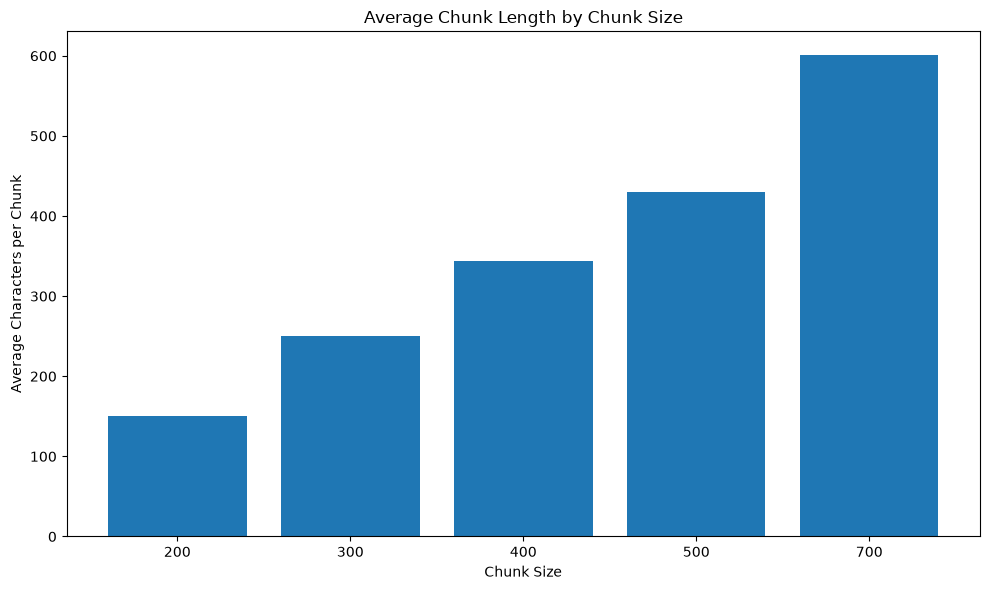

In [16]:
plt.figure(figsize=(10, 6))

plt.bar(
    stats_table["chunk_size"].astype(str),
    stats_table["avg_chars"]
)

plt.xlabel("Chunk Size")
plt.ylabel("Average Characters per Chunk")
plt.title("Average Chunk Length by Chunk Size")

plt.tight_layout()
plt.show()

#### Chunks per PDF (rows) for each chunk size (columns):

In [17]:
chunks_per_pdf = pd.DataFrame({
    size: Counter(c.metadata["source"] for c in chunks)
    for size, chunks in pdf_chunks_by_size.items()
}).fillna(0).astype(int)

chunks_per_pdf.index.name = "source"
chunks_per_pdf.columns.name = "chunk_size"
chunks_per_pdf.loc["TOTAL"] = chunks_per_pdf.sum()

chunks_per_pdf

chunk_size,200,300,400,500,700
source,,,,,
asthma_patient_information.pdf,40,26,19,15,11
who_cancer.pdf,724,453,327,260,191
who_cholera.pdf,1074,681,501,405,311
who_covid19_clinical.pdf,3878,2210,1564,1256,877
who_diabetes.pdf,136,82,60,48,36
who_hepatitis_bc.pdf,1888,1147,831,666,477
who_hiv_service_delivery.pdf,983,545,392,310,219
who_hypertension..pdf,1141,670,484,377,275
who_malaria.pdf,14064,8025,5763,4574,3210


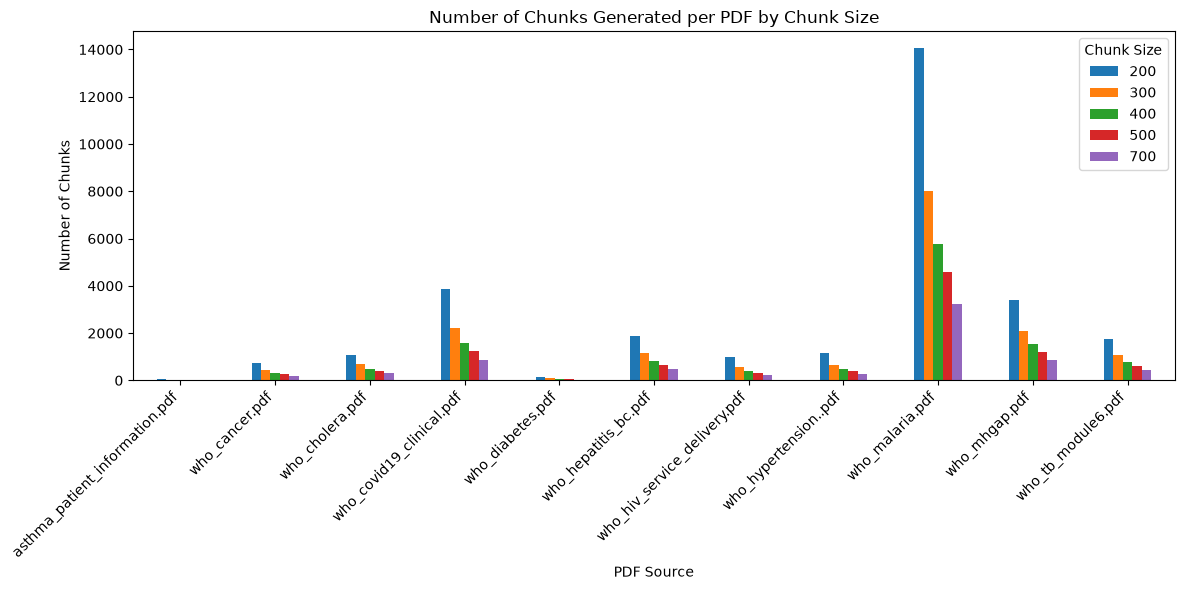

In [18]:
plot_data = chunks_per_pdf.drop(index="TOTAL")

plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("PDF Source")
plt.ylabel("Number of Chunks")
plt.title("Number of Chunks Generated per PDF by Chunk Size")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Chunk Size")
plt.tight_layout()
plt.show()

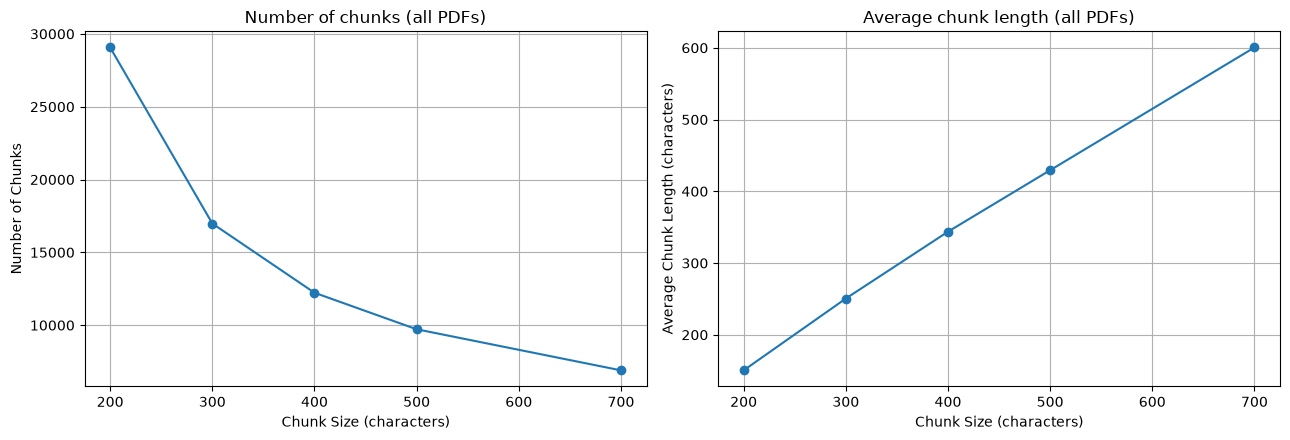

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(stats_table["chunk_size"], stats_table["num_chunks"], marker="o")
axes[0].set_xlabel("Chunk Size (characters)")
axes[0].set_ylabel("Number of Chunks")
axes[0].set_title("Number of chunks (all PDFs)")
axes[0].grid(True)

axes[1].plot(stats_table["chunk_size"], stats_table["avg_chars"], marker="o")
axes[1].set_xlabel("Chunk Size (characters)")
axes[1].set_ylabel("Average Chunk Length (characters)")
axes[1].set_title("Average chunk length (all PDFs)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

1) As the configured chunk size increases, the total number of generated chunks decreases substantially.
2) The average number of characters in the resulting chunks increases with the configured chunk size.

## 3. Embedding Model

`all-MiniLM-L6-v2` silently truncates input beyond its token limit, so the table below
shows how many chunks of each size would be cut off.

| Model | Max tokens | Dims | Notes |
|---|---:|---:|---|
| `all-MiniLM-L6-v2` | 256 | 384 | Fast, small, good baseline |
| `BAAI/bge-small-en-v1.5` | 512 | 384 | Same size and speed class, double the window, usually better retrieval |
| `BAAI/bge-base-en-v1.5` | 512 | 768 | Better quality, slower |
| `nomic-embed-text-v1.5` | 8192 | 768 | Long context, needs a task prefix like `search_document:` for documents and `search_query:` for queries. |
| `OpenAI text-embedding-3-small` | 8191 | 1536 | Paid API, billed per token. |


In [20]:
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
print(embedding_model)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({'module_input_name': 'sentence_embedding', 'module_output_name': 'sentence_embedding'})
)


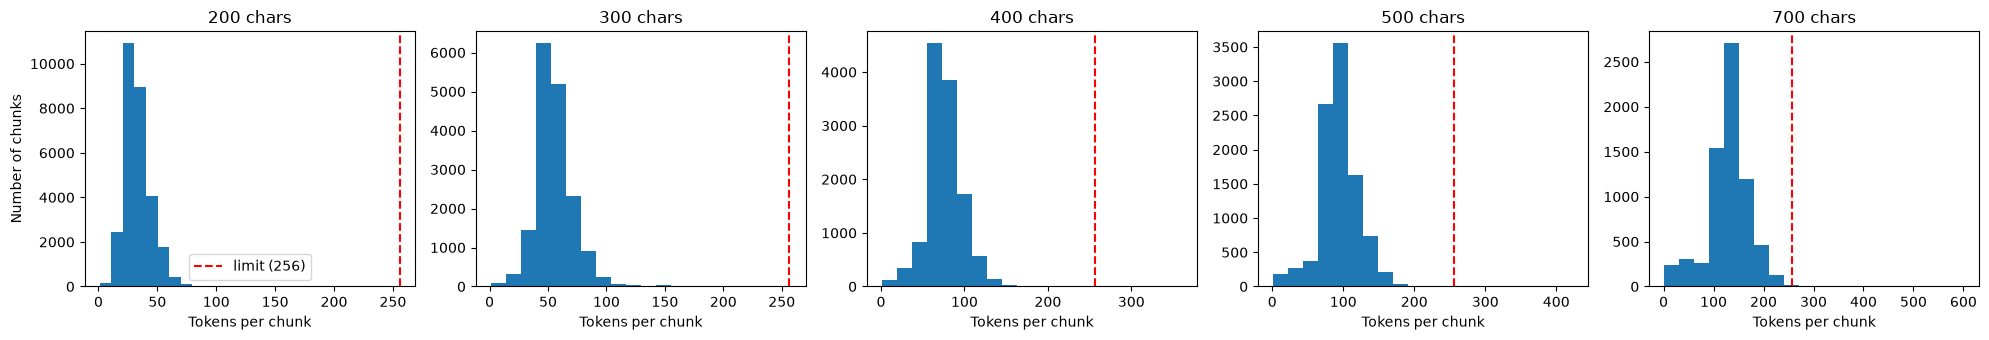

Token length vs model limit (pct is already a percentage: 0.81 = 0.81%)


,chunk_size,max_tokens,pct_over_model_limit
0,200,198,0.00
1,300,258,0.01
2,400,361,0.34
3,500,424,0.58
4,700,602,0.81



Chunk loss from truncation (absolute numbers)


,chunk_size,total_chunks,chunks_truncated,pct_truncated,max_tokens,avg_tokens_cut
0,200,29066,0,0.00,198,0.0
1,300,16980,1,0.01,258,2.0
2,400,12227,41,0.34,361,50.4
3,500,9720,56,0.58,424,71.7
4,700,6899,56,0.81,602,177.5



Truncated chunks per PDF (rows) for each chunk size (columns)


chunk_size,200,300,400,500,700
source,,,,,
asthma_patient_information.pdf,0,0,0,0,0
who_cancer.pdf,0,0,0,0,0
who_cholera.pdf,0,0,0,0,0
who_covid19_clinical.pdf,0,0,20,25,23
who_diabetes.pdf,0,0,0,0,0
who_hepatitis_bc.pdf,0,0,0,0,3
who_hiv_service_delivery.pdf,0,0,0,0,0
who_hypertension..pdf,0,0,0,0,0
who_malaria.pdf,0,0,21,28,24


In [21]:
from IPython.display import display

tokenizer = embedding_model.tokenizer
model_limit = embedding_model.max_seq_length  # 256 for all-MiniLM-L6-v2

# We only COUNT tokens here (nothing is truncated). Raising the tokenizer's length cap
# while counting just silences the harmless "sequence longer than maximum" warning;
# the embedding step still truncates to model_limit as usual.
_original_max_length = tokenizer.model_max_length
tokenizer.model_max_length = 10**9

token_lengths_by_size = {
    size: [
        len(tokenizer.encode(chunk.page_content, add_special_tokens=False))
        for chunk in chunks
    ]
    for size, chunks in pdf_chunks_by_size.items()
}

tokenizer.model_max_length = _original_max_length

# ---------------------------------------------------------------- histograms
fig, axes = plt.subplots(1, len(CHUNK_SIZES), figsize=(4 * len(CHUNK_SIZES), 3.5))
for ax, (size, lengths) in zip(np.atleast_1d(axes), token_lengths_by_size.items()):
    ax.hist(lengths, bins=20)
    ax.axvline(model_limit, color="red", linestyle="--", label=f"limit ({model_limit})")
    ax.set_title(f"{size} chars")
    ax.set_xlabel("Tokens per chunk")
np.atleast_1d(axes)[0].set_ylabel("Number of chunks")
np.atleast_1d(axes)[0].legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------- table 1: your original
token_limit_table = pd.DataFrame([
    {
        "chunk_size": size,
        "max_tokens": max(lengths),
        "pct_over_model_limit": round(100 * np.mean(np.array(lengths) > model_limit), 2),
    }
    for size, lengths in token_lengths_by_size.items()
])

print("Token length vs model limit (pct is already a percentage: 0.81 = 0.81%)")
display(token_limit_table)

# ---------------------------------------------------------------- table 2: chunk loss in numbers
truncation_rows = []

for size, lengths in token_lengths_by_size.items():
    lengths = np.array(lengths)
    over_limit = lengths > model_limit

    truncation_rows.append({
        "chunk_size": size,
        "total_chunks": len(lengths),
        "chunks_truncated": int(over_limit.sum()),
        "pct_truncated": round(100 * over_limit.mean(), 2),
        "max_tokens": int(lengths.max()),
        "avg_tokens_cut": round(float((lengths[over_limit] - model_limit).mean()), 1) if over_limit.any() else 0.0,
    })

truncation_table = pd.DataFrame(truncation_rows)

print("\nChunk loss from truncation (absolute numbers)")
display(truncation_table)

# ---------------------------------------------------------------- table 3: which PDFs
all_sources = sorted({c.metadata["source"] for c in pdf_chunks_by_size[CHUNK_SIZES[0]]})

truncated_by_pdf = pd.DataFrame(
    {
        size: [
            sum(
                1
                for chunk, n_tokens in zip(chunks, token_lengths_by_size[size])
                if chunk.metadata["source"] == source and n_tokens > model_limit
            )
            for source in all_sources
        ]
        for size, chunks in pdf_chunks_by_size.items()
    },
    index=all_sources,
)
truncated_by_pdf.index.name = "source"
truncated_by_pdf.columns.name = "chunk_size"
truncated_by_pdf.loc["TOTAL"] = truncated_by_pdf.sum()

print("\nTruncated chunks per PDF (rows) for each chunk size (columns)")
display(truncated_by_pdf)

In [22]:
pdf_embeddings_by_size = {}

for size, chunks in pdf_chunks_by_size.items():
    pdf_embeddings_by_size[size] = embedding_model.encode(
        [chunk.page_content for chunk in chunks],
        normalize_embeddings=True,
        batch_size=64,
        show_progress_bar=True,
    )

    print(f"Chunk size {size}: {pdf_embeddings_by_size[size].shape}")

Batches:   0%|          | 0/455 [00:00<?, ?it/s]

Chunk size 200: (29066, 384)


Batches:   0%|          | 0/266 [00:00<?, ?it/s]

Chunk size 300: (16980, 384)


Batches:   0%|          | 0/192 [00:00<?, ?it/s]

Chunk size 400: (12227, 384)


Batches:   0%|          | 0/152 [00:00<?, ?it/s]

Chunk size 500: (9720, 384)


Batches:   0%|          | 0/108 [00:00<?, ?it/s]

Chunk size 700: (6899, 384)


### Retrieval

The chunk embeddings are L2-normalized, so the dot product is the cosine similarity.
Retrieval runs over the chunks of **all** PDFs at once.

In [23]:
def rank_chunks(query_embedding, chunks, chunk_embeddings, top_k=TOP_K):
    """Return the top_k chunks for an already-embedded query."""
    similarities = chunk_embeddings @ query_embedding
    ranked_indices = np.argsort(similarities)[::-1][:top_k]

    return [
        {
            "rank": rank,
            "chunk_index": int(index),
            "score": float(similarities[index]),
            "chunk": chunks[index],
        }
        for rank, index in enumerate(ranked_indices, start=1)
    ]


def retrieve_chunks(query, chunks, chunk_embeddings, top_k=TOP_K):
    """Embed a text query and return the top_k chunks."""
    query_embedding = embedding_model.encode([query], normalize_embeddings=True)[0]
    return rank_chunks(query_embedding, chunks, chunk_embeddings, top_k)

## 4. Ground Truth

Questions live in `data/ground_truth.json`, one object per question:

```json
{
  "id": "diabetes_Q1",
  "source": "diabetes_guideline.pdf",
  "type": "fact",
  "question": "How is type 2 diabetes diagnosed?",
  "evidence": ["fasting plasma glucose", "HbA1c of 6.5%"]
}
```

- `id` must be unique across all PDFs.
- `source` is the filename of the PDF that contains the answer.
- `evidence` phrases are copied from that PDF. Case, whitespace, curly quotes and
  ligatures are ignored when matching. Keep them short so each phrase fits inside a single chunk.
- `type` is optional (for example `fact`, `paraphrase`, `multi`).

Validation checks every phrase against the **individual pages** of its PDF, because
chunks never cross page boundaries, so a phrase spanning two pages can never be retrieved.

In [24]:
def norm(text):
    """Normalize text for evidence matching."""
    text = unicodedata.normalize("NFKC", text)
    text = (
        text.replace("\u2019", "'").replace("\u2018", "'")
            .replace("\u201c", '"').replace("\u201d", '"')
            .replace("\u2013", "-").replace("\u2014", "-")
    )
    return re.sub(r"\s+", " ", text).lower().strip()


with open(GROUND_TRUTH_PATH, encoding="utf-8") as f:
    eval_questions = json.load(f)

print("Questions loaded:", len(eval_questions))

Questions loaded: 45


### Finding evidence phrases

Evidence must be copied from the *extracted* text, which can differ from what you see in a
PDF viewer (line breaks, hyphenation, table layout). `find_evidence` searches the extracted
pages and prints verbatim snippets with page numbers that you can paste into `ground_truth.json`.

In [44]:
def find_evidence(keyword, source=None, context=80, max_hits=10):
    """Search the extracted pages for a keyword and print copy-pasteable snippets."""
    hits = 0

    for d in documents:
        if source and d.metadata["source"] != source:
            continue

        text = re.sub(r"\s+", " ", d.page_content)

        for match in re.finditer(re.escape(keyword), text, flags=re.IGNORECASE):
            start = max(0, match.start() - context)
            end = min(len(text), match.end() + context)

            print(f"[{d.metadata['source']} | p.{d.metadata['page']}]  ...{text[start:end]}...")
            hits += 1

            if hits >= max_hits:
                print(f"(stopped after {max_hits} hits)")
                return

    if hits == 0:
        print(f"No matches for {keyword!r}. Try a shorter keyword or a different spelling.")


# Example:
find_evidence("Colds and viruses", source="asthma_patient_information.pdf")

[asthma_patient_information.pdf | p.2]  ...or inflames your airways can make your asthma worse. Common triggers include: • Colds and viruses • Allergies – e.g. animal hair, pollen • Dust / Pollution / Smoke • Stress or h...


In [28]:
def validate_ground_truth(questions, documents, max_phrase_chars):
    """Check ids, sources and evidence phrases before spending time on evaluation."""

    page_texts = {}
    for d in documents:
        page_texts.setdefault(d.metadata["source"], []).append(norm(d.page_content))

    problems, warnings, seen_ids = [], [], set()

    for q in questions:
        qid = q.get("id", "<no id>")

        for field in ("id", "source", "question", "evidence"):
            if not q.get(field):
                problems.append(f"{qid}: missing or empty '{field}'")

        if qid in seen_ids:
            problems.append(f"{qid}: duplicate id")
        seen_ids.add(qid)

        source = q.get("source")
        if source not in page_texts:
            problems.append(f"{qid}: source '{source}' is not one of the loaded PDFs")
            continue

        for phrase in q.get("evidence", []):
            if not any(norm(phrase) in page for page in page_texts[source]):
                problems.append(f"{qid}: evidence not found on any single page of {source} -> {phrase!r}")
            if len(phrase) > max_phrase_chars:
                warnings.append(f"{qid}: evidence is {len(phrase)} chars (> {max_phrase_chars}); may not fit in one chunk -> {phrase[:50]!r}...")

    for w in warnings:
        print("WARNING:", w)
    for p in problems:
        print("ERROR:  ", p)
    assert not problems, f"{len(problems)} ground-truth problem(s) - fix them and re-run."

    questions_per_pdf = Counter(q["source"] for q in questions)
    print("Ground truth OK. Questions per PDF:")
    for name in sorted(page_texts):
        count = questions_per_pdf.get(name, 0)
        note = "" if count else "  (no questions - acts only as a distractor document)"
        print(f"  {name}: {count}{note}")


validate_ground_truth(
    eval_questions,
    documents,
    max_phrase_chars=min(CHUNK_SIZES) - CHUNK_OVERLAP,
)

Ground truth OK. Questions per PDF:
  asthma_patient_information.pdf: 12
  who_cancer.pdf: 0  (no questions - acts only as a distractor document)
  who_cholera.pdf: 20
  who_covid19_clinical.pdf: 0  (no questions - acts only as a distractor document)
  who_diabetes.pdf: 0  (no questions - acts only as a distractor document)
  who_hepatitis_bc.pdf: 0  (no questions - acts only as a distractor document)
  who_hiv_service_delivery.pdf: 0  (no questions - acts only as a distractor document)
  who_hypertension.pdf: 13
  who_malaria.pdf: 0  (no questions - acts only as a distractor document)
  who_mhgap.pdf: 0  (no questions - acts only as a distractor document)
  who_tb_module6.pdf: 0  (no questions - acts only as a distractor document)


## 5. Retrieval Evaluation

For every chunk size and every question, the top 5 chunks are retrieved from the shared
index, and Precision, Recall, Hit rate and MRR are computed at k = 1, 3 and 5.

In [29]:
def score_ranked_list(evidence, source, ranked, ks):
    """
    Score one question.

    ranked: list of (normalized_chunk_text, chunk_source) in rank order.
    Returns {k: {precision, recall, hit_rate, mrr}}.
    """
    phrases = [norm(e) for e in evidence]

    is_relevant = [
        chunk_source == source and any(p in text for p in phrases)
        for text, chunk_source in ranked
    ]

    scores = {}
    for k in ks:
        window = ranked[:k]
        flags = is_relevant[:k]

        # Evidence recall only counts chunks from the correct PDF
        window_texts = [text for text, chunk_source in window if chunk_source == source]
        recall = sum(any(p in t for t in window_texts) for p in phrases) / len(phrases)

        first_relevant_rank = next((r for r, f in enumerate(flags, start=1) if f), None)

        scores[k] = {
            "precision": sum(flags) / k,
            "recall": recall,
            "hit_rate": float(any(flags)),
            "mrr": 1 / first_relevant_rank if first_relevant_rank else 0.0,
        }

    return scores

In [31]:
# Pre-compute normalized chunk text once per chunk size
norm_texts_by_size = {
    size: [norm(c.page_content) for c in chunks]
    for size, chunks in pdf_chunks_by_size.items()
}

# Embed all questions in one batch
question_embeddings = embedding_model.encode(
    [q["question"] for q in eval_questions],
    normalize_embeddings=True,
)

eval_rows = []

for size, chunks in pdf_chunks_by_size.items():
    for q, q_embedding in zip(eval_questions, question_embeddings):

        results = rank_chunks(q_embedding, chunks, pdf_embeddings_by_size[size], TOP_K)

        ranked = [
            (norm_texts_by_size[size][r["chunk_index"]], chunks[r["chunk_index"]].metadata["source"])
            for r in results
        ]

        for k, scores in score_ranked_list(q["evidence"], q["source"], ranked, K_VALUES).items():
            eval_rows.append({
                "chunk_size": size,
                "k": k,
                "id": q["id"],
                "source": q["source"],
                "type": q.get("type", "unlabeled"),
                **scores,
            })

eval_df = pd.DataFrame(eval_rows)
print(f"{len(eval_questions)} questions x {len(CHUNK_SIZES)} chunk sizes x {len(K_VALUES)} k values = {len(eval_df)} rows")

45 questions x 5 chunk sizes x 3 k values = 675 rows


### Complete results table

Mean Precision, Recall, Hit rate and MRR for every chunk size and every k.

In [32]:
METRICS = ["precision", "recall", "hit_rate", "mrr"]

summary = eval_df.groupby(["chunk_size", "k"])[METRICS].mean().round(3)
summary

precision  recall  hit_rate    mrr
chunk_size k                                    
200        1      0.178   0.122     0.178  0.178
           3      0.148   0.267     0.356  0.256
           5      0.124   0.394     0.467  0.281
300        1      0.378   0.324     0.378  0.378
           3      0.200   0.458     0.511  0.441
           5      0.164   0.569     0.644  0.472
400        1      0.400   0.300     0.400  0.400
           3      0.237   0.537     0.600  0.493
           5      0.173   0.630     0.711  0.519
500        1      0.400   0.357     0.400  0.400
           3      0.259   0.649     0.711  0.537
           5      0.191   0.726     0.756  0.547
700        1      0.444   0.404     0.444  0.444
           3      0.274   0.637     0.689  0.556
           5      0.196   0.748     0.800  0.579

Same numbers, wide format (one column per metric and k):

In [33]:
summary.unstack("k")

precision               recall               hit_rate         \
k                  1      3      5      1      3      5        1      3   
chunk_size                                                                
200            0.178  0.148  0.124  0.122  0.267  0.394    0.178  0.356   
300            0.378  0.200  0.164  0.324  0.458  0.569    0.378  0.511   
400            0.400  0.237  0.173  0.300  0.537  0.630    0.400  0.600   
500            0.400  0.259  0.191  0.357  0.649  0.726    0.400  0.711   
700            0.444  0.274  0.196  0.404  0.637  0.748    0.444  0.689   

                     mrr                
k               5      1      3      5  
chunk_size                              
200         0.467  0.178  0.256  0.281  
300         0.644  0.378  0.441  0.472  
400         0.711  0.400  0.493  0.519  
500         0.756  0.400  0.537  0.547  
700         0.800  0.444  0.556  0.579

### Best chunk size per metric

For each k, the chunk size with the highest score (ties go to the smaller size).

In [34]:
best_chunk_size = pd.DataFrame({
    metric: summary[metric].unstack("k").idxmax()
    for metric in METRICS
})
best_chunk_size.index.name = "k"

best_chunk_size

,precision,recall,hit_rate,mrr
k,,,,
1,700,700,700,700
3,700,500,500,700
5,700,700,700,700


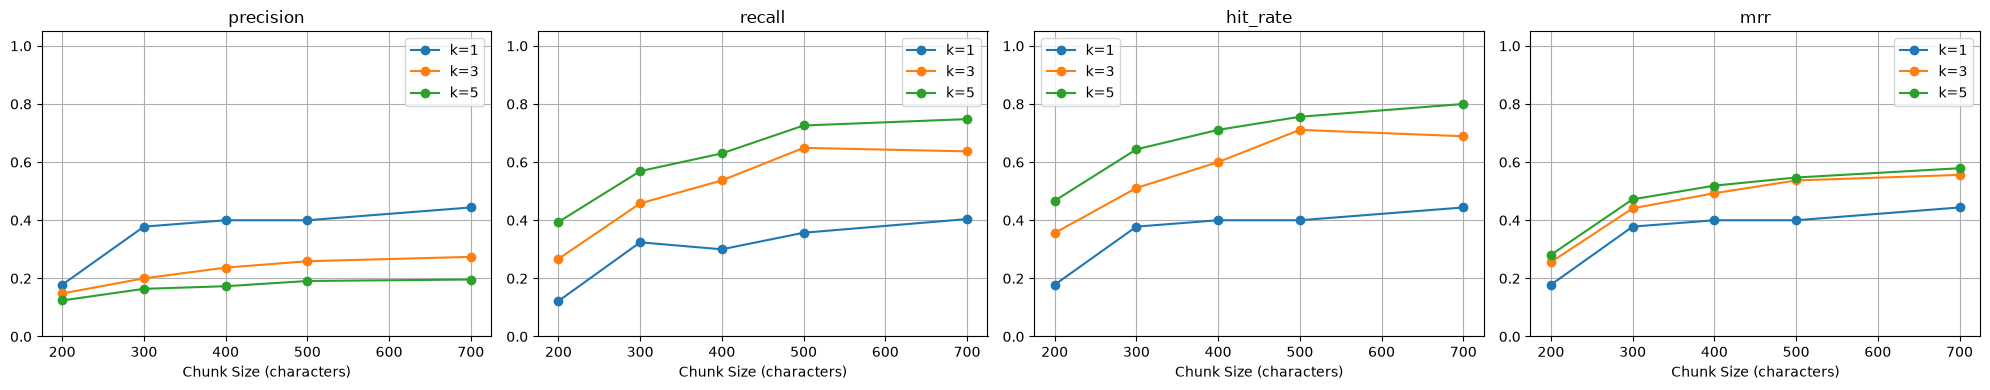

In [35]:
fig, axes = plt.subplots(1, len(METRICS), figsize=(5 * len(METRICS), 4))

for ax, metric in zip(axes, METRICS):
    for k in K_VALUES:
        series = summary.xs(k, level="k")[metric]
        ax.plot(series.index, series.values, marker="o", label=f"k={k}")

    ax.set_title(metric)
    ax.set_xlabel("Chunk Size (characters)")
    ax.set_ylim(0, 1.05)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

### Per-PDF breakdown (k = 5)

Shows whether one document is dragging the average down.

In [36]:
per_pdf = (
    eval_df[eval_df["k"] == TOP_K]
    .groupby(["source", "chunk_size"])
    .agg(
        questions=("id", "nunique"),
        precision=("precision", "mean"),
        recall=("recall", "mean"),
        hit_rate=("hit_rate", "mean"),
        mrr=("mrr", "mean"),
    )
    .round(3)
)

per_pdf

questions  precision  recall  \
source                         chunk_size                                 
asthma_patient_information.pdf 200                12      0.167   0.396   
                               300                12      0.200   0.689   
                               400                12      0.217   0.847   
                               500                12      0.217   0.807   
                               700                12      0.167   0.750   
who_cholera.pdf                200                20      0.120   0.525   
                               300                20      0.150   0.592   
                               400                20      0.150   0.625   
                               500                20      0.180   0.750   
                               700                20      0.200   0.850   
who_hypertension.pdf           200                13      0.092   0.192   
                               300                13      0.154   0.423   
                               400                13      0.169   0.436   
                               500                13      0.185   0.615   
                               700                13      0.215   0.590   

                                           hit_rate    mrr  
source                         chunk_size                   
asthma_patient_information.pdf 200            0.500  0.257  
                               300            0.833  0.658  
                               400            0.917  0.750  
                               500            0.917  0.708  
                               700            0.833  0.517  
who_cholera.pdf                200            0.550  0.345  
                               300            0.650  0.429  
                               400            0.700  0.431  
                               500            0.750  0.529  
                               700            0.900  0.682  
who_hypertension.pdf           200            0.308  0.205  
                               300            0.462  0.365  
                               400            0.538  0.442  
                               500            0.615  0.426  
                               700            0.615  0.477

### Questions that failed

Questions with no relevant chunk in the top 5. Use `show_retrieval_results` below to see why.

In [37]:
misses = (
    eval_df[(eval_df["k"] == TOP_K) & (eval_df["hit_rate"] == 0)]
    [["id", "source", "type", "chunk_size"]]
    .sort_values(["id", "chunk_size"])
    .reset_index(drop=True)
)

print(f"{len(misses)} misses at k={TOP_K}")
misses

73 misses at k=5


,id,source,type,chunk_size
0,asthma_Q1,asthma_patient_information.pdf,fact,200
1,asthma_Q4,asthma_patient_information.pdf,multi,200
2,asthma_Q5,asthma_patient_information.pdf,multi,200
3,asthma_Q5,asthma_patient_information.pdf,multi,400
4,asthma_Q5,asthma_patient_information.pdf,multi,700
...,...,...,...,...
68,htn_Q6,who_hypertension.pdf,paraphrase,500
69,htn_Q6,who_hypertension.pdf,paraphrase,700
70,htn_Q8,who_hypertension.pdf,fact,200
71,htn_Q8,who_hypertension.pdf,fact,300


In [38]:
def show_retrieval_results(question_id, chunk_size, top_k=TOP_K):
    """Print the top-k chunks for one question and mark which ones are relevant."""

    q = next(q for q in eval_questions if q["id"] == question_id)
    chunks = pdf_chunks_by_size[chunk_size]

    results = retrieve_chunks(
        q["question"], chunks, pdf_embeddings_by_size[chunk_size], top_k=top_k
    )

    phrases = [norm(e) for e in q["evidence"]]

    print("=" * 80)
    print(f"{question_id}: {q['question']}")
    print(f"Expected source: {q['source']} | Chunk size: {chunk_size}")
    print("=" * 80)

    for r in results:
        chunk = r["chunk"]
        meta = chunk.metadata
        relevant = (
            meta["source"] == q["source"]
            and any(p in norm(chunk.page_content) for p in phrases)
        )

        print(
            f"\nRank {r['rank']} | {meta['source']} p.{meta['page']} | "
            f"chunk {r['chunk_index']} | sim {r['score']:.4f} | "
            f"{'RELEVANT' if relevant else '-'}"
        )
        print("-" * 80)
        print(chunk.page_content)


show_retrieval_results(eval_questions[0]["id"], CHUNK_SIZES[0])

asthma_Q1: What are the common symptoms of asthma?
Expected source: asthma_patient_information.pdf | Chunk size: 200

Rank 1 | asthma_patient_information.pdf p.3 | chunk 27 | sim 0.6222 | -
--------------------------------------------------------------------------------
• Your asthma does not interfere with your normal daily activities 
• You do not wake at night with asthma symptoms 
• You haven’t had a recent attack 
 
Is asthma serious?

Rank 2 | asthma_patient_information.pdf p.2 | chunk 14 | sim 0.5981 | -
--------------------------------------------------------------------------------
• Temperature extremes / temperature change 
• Hormones 
• Strong smells – e.g. perfumes, aerosols, cleaning products 
Some people can have exercise induced asthma but using a reliever medication

Rank 3 | asthma_patient_information.pdf p.3 | chunk 29 | sim 0.5956 | -
--------------------------------------------------------------------------------
symptoms flare up. However, around 5% of all people 